In [1]:
import pandas as pd

# The key is 'lines=True'
df = pd.read_json('problems_data.jsonl', lines=True)

print(df.head())
print(df.shape)

                       title  \
0                        Uuu   
1             House Building   
2             Mario or Luigi   
3             The Wire Ghost   
4  Barking Up The Wrong Tree   

                                         description  \
0  Unununium (Uuu) was the name of the chemical\n...   
1  A number of eccentrics from central New York h...   
2  Mario and Luigi are playing a game where they ...   
3  Žofka is bending a copper wire. She starts wit...   
4  Your dog Spot is let loose in the park. Well, ...   

                                   input_description  \
0  The input consists of one line with two intege...   
1  The input consists of $10$ test cases, which a...   
2                                                      
3  The first line contains two integers $L$ and $...   
4  The first line of input consists of two intege...   

                                  output_description  \
0  The output consists of $M$ lines where the $i$...   
1  Print $K$ lines wi

In [2]:

# Display initial missing value counts
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
title                 0
description           0
input_description     0
output_description    0
sample_io             0
problem_class         0
problem_score         0
url                   0
dtype: int64


In [3]:
# Replace NaN in text columns with empty strings
text_columns = ['title', 'description', 'input_description', 'output_description']
for col in text_columns:
    df[col] = df[col].fillna("")

# Replace NaN in the numerical target (problem_score) with the median
# or 0, depending on your preference. Median is usually safer.
df['problem_score'] = df['problem_score'].fillna(df['problem_score'].median())

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
title                 0
description           0
input_description     0
output_description    0
sample_io             0
problem_class         0
problem_score         0
url                   0
dtype: int64


In [4]:
import re

def basic_clean(text):
    # Convert to lowercase
    text = text.lower()
    # Remove extra whitespaces/newlines
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Create the combined field
df["combined_text"] = (
    df["title"] + " " +
    df["description"] + " " +
    df["input_description"] + " " +
    df["output_description"]
)

# Apply cleaning
df["combined_text"] = df["combined_text"].apply(basic_clean)

# Show a sample of the cleaned, combined text
print("\nSample Cleaned Text:")
print(df["combined_text"].iloc[0][:200] + "...")


Sample Cleaned Text:
uuu unununium (uuu) was the name of the chemical element with atom number 111, until it changed to röntgenium (rg) in 2004. these heavy elements are very unstable and have only been synthesized in a f...


In [5]:
# Map labels to logical order: 0 (Easy), 1 (Medium), 2 (Hard)
mapping = {'easy': 0, 'medium': 1, 'hard': 2}
df['class_target'] = df['problem_class'].str.lower().map(mapping).fillna(1).astype(int)

# Check if any labels failed to map
if df['class_target'].isnull().any():
    print("Warning: Some problem_class labels were not recognized and are now NaN.")

In [6]:
# Keyword frequency
keywords = ["graph", "dp",  "recursion", "tree", "greedy" , "bitmask" , "binary search" , "geometry" , "data structures" , "brute force" ]

for kw in keywords:
    df[f"kw_{kw}"] = df["combined_text"].apply(lambda x: x.count(kw))

In [7]:
def extract_max_constraint(text):
    # Find patterns like 10^5, 10**9, or 1e6
    scientific = re.findall(r'10\s*[\^|\*\*]\s*(\d+)', text)
    e_notation = re.findall(r'1e(\d+)', text)

    # Combine and convert to log10 values (e.g., 10^9 becomes 9)
    powers = [int(p) for p in scientific + e_notation]

    # Also look for standard large numbers like 1000000
    large_ints = re.findall(r'\b\d{5,18}\b', text)
    if large_ints:
        powers.extend([len(x)-1 for x in large_ints])

    return max(powers) if powers else 0

df['log_constraint'] = df['combined_text'].apply(extract_max_constraint)

In [8]:
# Vocabulary groups
hard_vocab = ["query", "update", "segment", "flow", "matching", "modulo", "prime", "sieve"]
easy_vocab = ["print", "output", "calculate", "sum", "simple", "integer", "convert"]

df['hard_word_score'] = df['combined_text'].apply(lambda x: sum(x.count(w) for w in hard_vocab))
df['easy_word_score'] = df['combined_text'].apply(lambda x: sum(x.count(w) for w in easy_vocab))

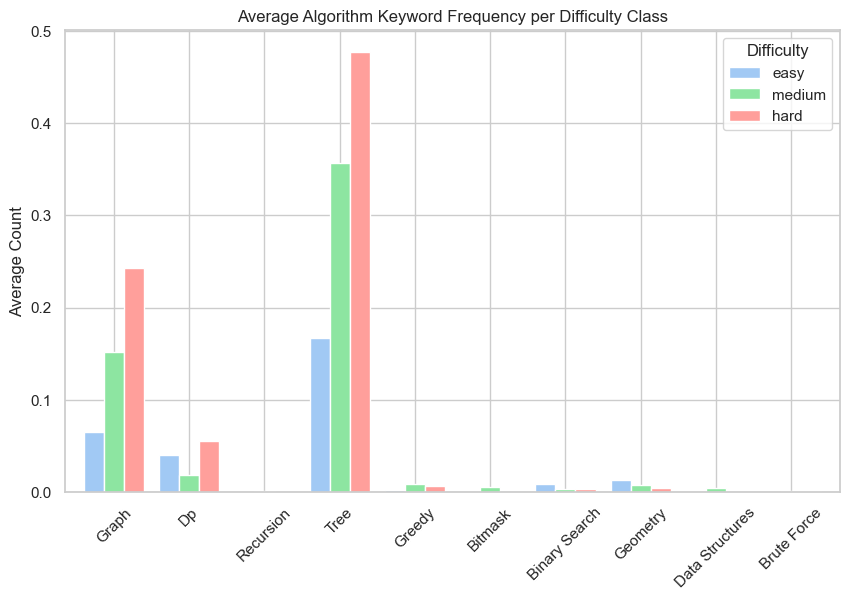

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

sns.set_theme(style="whitegrid")

# Define exactly which features we want to see
# We only plot if they are in the dataframe to avoid the ValueError
main_features = ['text_length', 'math_symbol_count']
kw_cols = [f"kw_{k}" for k in keywords]

# Filter main_features to only those that exist
existing_main = [f for f in main_features if f in df.columns]

if existing_main:
    plt.figure(figsize=(12, 5))
    for i, col in enumerate(existing_main):
        plt.subplot(1, len(existing_main), i + 1)
        sns.boxplot(x='problem_class', y=col, data=df,
                    order=['easy', 'medium', 'hard'], palette='Blues')
        plt.title(f'{col.replace("_", " ").title()} by Class')
    plt.tight_layout()
    plt.show()

# 3. KEYWORD PLOT
existing_kw = [c for c in kw_cols if c in df.columns]
if existing_kw:
    kw_trends = df.groupby('problem_class')[existing_kw].mean().reindex(['easy', 'medium', 'hard'])
    kw_trends.columns = [c.replace('kw_', '').title() for c in kw_trends.columns]

    kw_trends.T.plot(kind='bar', figsize=(10, 6), width=0.8, color=['#A1C9F4', '#8DE5A1', '#FF9F9B'])
    plt.title('Average Algorithm Keyword Frequency per Difficulty Class')
    plt.ylabel('Average Count')
    plt.xticks(rotation=45)
    plt.legend(title='Difficulty')
    plt.show()

In [10]:
df["problem_class"].value_counts()


problem_class
hard      1941
medium    1405
easy       766
Name: count, dtype: int64

In [11]:
df["problem_score"].describe()

count    4112.000000
mean        5.114689
std         2.177770
min         1.100000
25%         3.300000
50%         5.200000
75%         6.900000
max         9.700000
Name: problem_score, dtype: float64

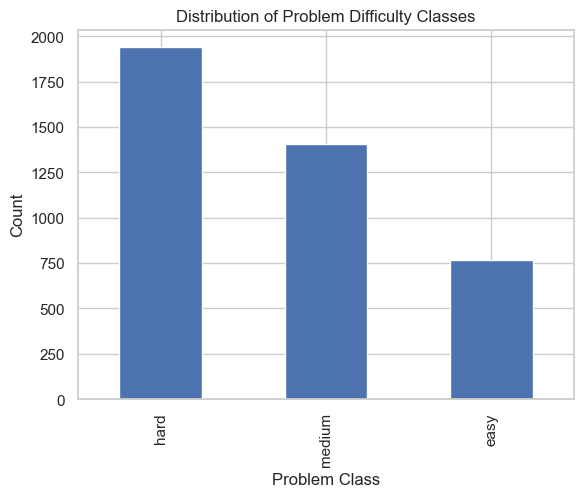

In [12]:
import matplotlib.pyplot as plt

class_counts = df["problem_class"].value_counts()

plt.figure()
class_counts.plot(kind="bar")
plt.title("Distribution of Problem Difficulty Classes")
plt.xlabel("Problem Class")
plt.ylabel("Count")
plt.show()


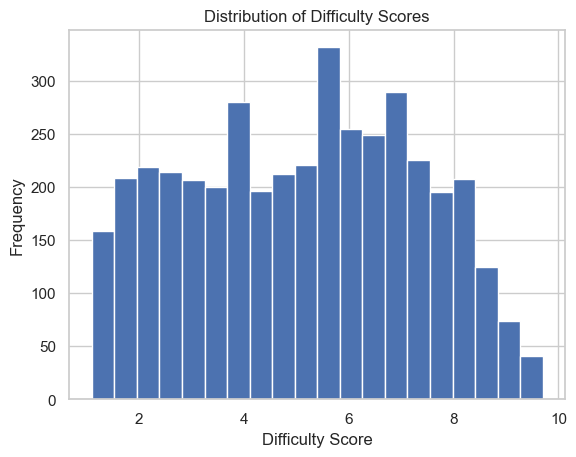

In [13]:
plt.figure()
plt.hist(df["problem_score"], bins=20)
plt.title("Distribution of Difficulty Scores")
plt.xlabel("Difficulty Score")
plt.ylabel("Frequency")
plt.show()


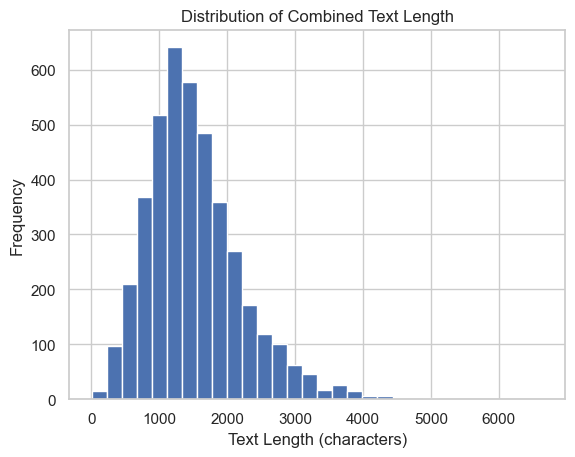

In [14]:
text_lengths = df["combined_text"].apply(len)

plt.figure()
plt.hist(text_lengths, bins=30)
plt.title("Distribution of Combined Text Length")
plt.xlabel("Text Length (characters)")
plt.ylabel("Frequency")
plt.show()


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# 1. Ensure all manual features are calculated in the main dataframe
df["text_length"] = df["combined_text"].apply(len)

math_symbols = "+-*/=<>^"
df["math_symbol_count"] = df["combined_text"].apply(
    lambda x: sum(x.count(s) for s in math_symbols)
)

keywords = ["graph", "dp",  "recursion", "tree", "greedy" , "bitmask" , "binary search" , "geometry" , "data structures" , "brute force" ]
for kw in keywords:
    df[f"kw_{kw}"] = df["combined_text"].apply(lambda x: x.count(kw))

# 2. Vectorize the text
vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), stop_words='english')
X_tfidf = vectorizer.fit_transform(df["combined_text"])

# 3. Create the manual feature matrix
manual_cols = ["text_length", "math_symbol_count"] + [f"kw_{k}" for k in keywords]
X_manual = df[manual_cols].values

# 4. Horizontally stack the TF-IDF (sparse) and Manual (dense) features
X_final = hstack([X_tfidf, X_manual])

print(f"Final Feature Matrix Shape: {X_final.shape}")
print("Features assembled successfully!")

Final Feature Matrix Shape: (4112, 2012)
Features assembled successfully!


In [16]:
from sklearn.model_selection import train_test_split

# Split data (80% training, 20% testing)
X_train, X_test, y_class_train, y_class_test, y_score_train, y_score_test = train_test_split(
    X_final, df['class_target'], df['problem_score'], test_size=0.2, random_state=42
)

In [18]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import matplotlib.pyplot as plt
import numpy as np

--- Logistic Regression Classification Analysis ---

========== Logistic Regression ==========
Final Accuracy: 0.4411
Macro F1 Score: 0.4099
------------------------------
              precision    recall  f1-score   support

        Easy       0.32      0.34      0.33       136
      Medium       0.34      0.40      0.37       262
        Hard       0.57      0.50      0.53       425

    accuracy                           0.44       823
   macro avg       0.41      0.41      0.41       823
weighted avg       0.46      0.44      0.45       823



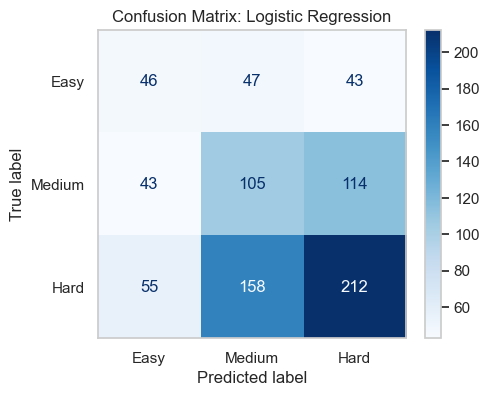

In [19]:
from sklearn.metrics import accuracy_score, f1_score

print("--- Logistic Regression Classification Analysis ---")

# 1. Initialize and Fit
log_clf = make_pipeline(
    StandardScaler(with_mean=False),
    LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
)
log_clf.fit(X_train, y_class_train)

# 2. Generate Predictions
log_pred = log_clf.predict(X_test)

# 3. Enhanced Metric Function
def evaluate_classification_enhanced(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    print(f"\n{'='*10} {name} {'='*10}")
    print(f"Final Accuracy: {acc:.4f}")
    print(f"Macro F1 Score: {macro_f1:.4f}")
    print("-" * 30)
    print(classification_report(y_true, y_pred, target_names=['Easy', 'Medium', 'Hard']))

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Easy', 'Medium', 'Hard'])
    disp.plot(cmap='Blues', ax=ax)
    plt.title(f"Confusion Matrix: {name}")
    plt.grid(False)
    plt.show()

# 4. Execute
evaluate_classification_enhanced("Logistic Regression", y_class_test, log_pred)

--- SVM Classification Analysis ---

========== SVM (Linear) ==========
Final Accuracy: 0.4447
Macro F1 Score: 0.4207
------------------------------
              precision    recall  f1-score   support

        Easy       0.32      0.46      0.38       136
      Medium       0.33      0.35      0.34       262
        Hard       0.60      0.50      0.55       425

    accuracy                           0.44       823
   macro avg       0.42      0.44      0.42       823
weighted avg       0.47      0.44      0.45       823



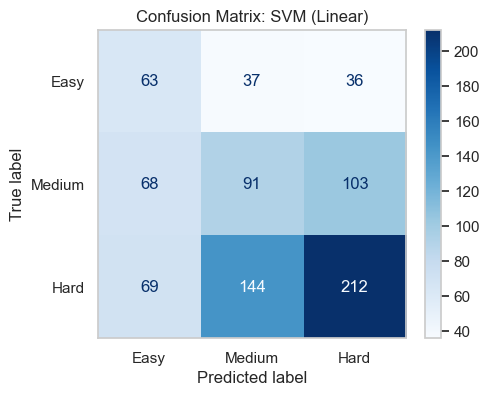

In [20]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.svm import SVC

print("--- SVM Classification Analysis ---")

svm_clf = make_pipeline(
    StandardScaler(with_mean=False),
    SVC(kernel='linear', class_weight='balanced', random_state=42)
)
svm_clf.fit(X_train, y_class_train)

svm_pred = svm_clf.predict(X_test)

# Using the enhanced function defined above
evaluate_classification_enhanced("SVM (Linear)", y_class_test, svm_pred)

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("--- Linear Regression Analysis ---")

# 1. Initialize and Fit
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_score_train)

# 2. Predict
lin_pred = lin_reg.predict(X_test)

# 3. Evaluate
# Re-using the logic from your previous evaluate_regression block
def evaluate_regression_local(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name} Results:")
    print(f"MAE:      {mae:.4f}")
    print(f"RMSE:     {rmse:.4f}")

evaluate_regression_local("Linear Regression", y_score_test, lin_pred)

--- Linear Regression Analysis ---

Linear Regression Results:
MAE:      2.2981
RMSE:     2.8809


In [22]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print("--- Ridge Regression Analysis ---")

# 1. Initialize and Fit
# Alpha controls the strength of regularization
ridge_reg = make_pipeline(
    StandardScaler(with_mean=False),
    Ridge(alpha=1.0, random_state=42)
)

ridge_reg.fit(X_train, y_score_train)

# 2. Predict
ridge_pred = ridge_reg.predict(X_test)

# 3. Evaluate
evaluate_regression_local("Ridge Regression", y_score_test, ridge_pred)

--- Ridge Regression Analysis ---

Ridge Regression Results:
MAE:      2.4314
RMSE:     3.0655


In [23]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, mean_absolute_error
import pandas as pd

In [24]:
# Initialize Models
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
xgb_clf = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)

--- Final Classification Metrics Comparison ---

========== Random Forest Classifier ==========
Final Accuracy: 0.5577
Macro F1 Score: 0.4717
------------------------------
              precision    recall  f1-score   support

        Easy       0.52      0.37      0.43       136
      Medium       0.43      0.23      0.29       262
        Hard       0.60      0.82      0.69       425

    accuracy                           0.56       823
   macro avg       0.51      0.47      0.47       823
weighted avg       0.53      0.56      0.52       823



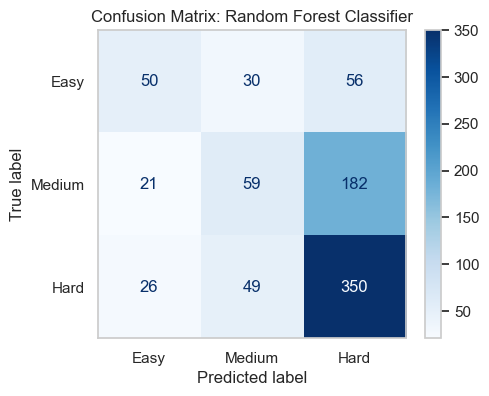


========== XGBoost Classifier ==========
Final Accuracy: 0.5553
Macro F1 Score: 0.4769
------------------------------
              precision    recall  f1-score   support

        Easy       0.52      0.34      0.41       136
      Medium       0.40      0.28      0.33       262
        Hard       0.61      0.80      0.69       425

    accuracy                           0.56       823
   macro avg       0.51      0.47      0.48       823
weighted avg       0.53      0.56      0.53       823



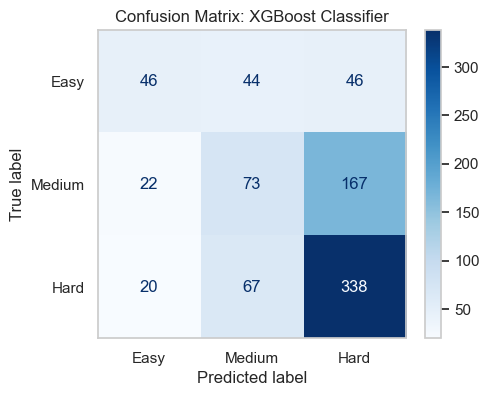

In [25]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score, f1_score
)
import matplotlib.pyplot as plt

# --- 1. CLASSIFICATION METRICS ---
print("--- Final Classification Metrics Comparison ---")

# Ensure models are fitted
rf_clf.fit(X_train, y_class_train)
xgb_clf.fit(X_train, y_class_train)

# Predictions
rf_class_pred = rf_clf.predict(X_test)
xgb_class_pred = xgb_clf.predict(X_test)

def evaluate_classification_complete(name, y_true, y_pred):
    # Calculate specific metrics for direct comparison
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    print(f"\n{'='*10} {name} {'='*10}")
    print(f"Final Accuracy: {acc:.4f}")
    print(f"Macro F1 Score: {macro_f1:.4f}")
    print("-" * 30)
    print(classification_report(y_true, y_pred, target_names=['Easy', 'Medium', 'Hard']))

    # Plot Confusion Matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Easy', 'Medium', 'Hard'])
    disp.plot(cmap='Blues', ax=ax)
    plt.title(f"Confusion Matrix: {name}")
    plt.grid(False) # Clean look
    plt.show()

# Run Evaluation
evaluate_classification_complete("Random Forest Classifier", y_class_test, rf_class_pred)
evaluate_classification_complete("XGBoost Classifier", y_class_test, xgb_class_pred)

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Initialize the models (if not already done)
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
xgb_reg = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)

# 2. FIT the models (This is the missing step that fixes the error)
print("Fitting models to training data...")
rf_reg.fit(X_train, y_score_train)
xgb_reg.fit(X_train, y_score_train)



Fitting models to training data...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [27]:
# 3. Predict on the test set
print("Generating predictions...")
rf_score_pred = rf_reg.predict(X_test)
xgb_score_pred = xgb_reg.predict(X_test)

# 4. Evaluation Function
def evaluate_regression(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"\n{name} Results:")
    print(f"MAE:      {mae:.4f}")
    print(f"RMSE:     {rmse:.4f}")

# 5. Run the evaluation
evaluate_regression("Random Forest Regressor", y_score_test, rf_score_pred)
evaluate_regression("XGBoost Regressor", y_score_test, xgb_score_pred)

Generating predictions...

Random Forest Regressor Results:
MAE:      1.6862
RMSE:     2.0382

XGBoost Regressor Results:
MAE:      1.7014
RMSE:     2.0416


In [30]:
'''import joblib
#  random forest  performed best (common for textual features)
# Save the trained models
joblib.dump(rf_clf, 'best_classifier.pkl')
joblib.dump(rf_reg, 'best_regressor.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("Models and Vectorizer saved successfully!")'''

'import joblib\n#  random forest  performed best (common for textual features)\n# Save the trained models\njoblib.dump(rf_clf, \'best_classifier.pkl\')\njoblib.dump(rf_reg, \'best_regressor.pkl\')\njoblib.dump(vectorizer, \'tfidf_vectorizer.pkl\')\n\nprint("Models and Vectorizer saved successfully!")'

In [31]:
import joblib
import os

# 1. Save with high compression (Level 3 is usually enough, Level 9 is maximum)
joblib.dump(rf_clf, 'best_classifier.pkl', compress=9)
joblib.dump(rf_reg, 'best_regressor.pkl', compress=9)
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl', compress=9)

['tfidf_vectorizer.pkl']